Total Time Steps: 1000
Total Updates Sent: 21
Communication Saved: 97.9%


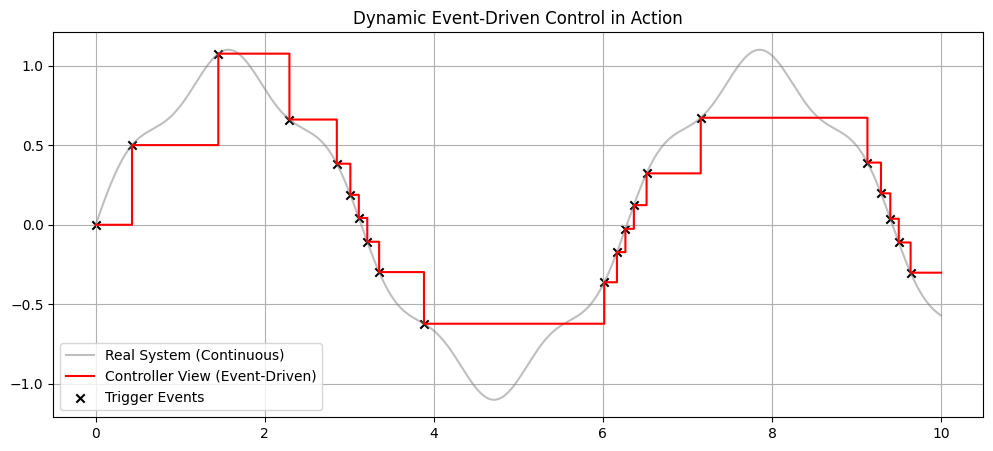

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. THE DYNAMIC EVENT-DRIVEN CLASS (The Core Innovation) ---
class DynamicEventTrigger:
    def __init__(self, alpha=0.5, beta=0.2, gamma_init=1.0):
        self.alpha = alpha  # Threshold parameter
        self.beta = beta    # Decay rate (How fast 'patience' runs out)
        self.gamma = gamma_init # The "Internal Dynamic Variable"
        self.last_sent_state = None
        self.triggered_times = []

    def check_trigger(self, t, current_state, dt):
        """
        Decides if we should wake up the controller.
        Returns: True (Wake Up!) or False (Sleep)
        """
        # If it's the first step, always trigger
        if self.last_sent_state is None:
            self.last_sent_state = current_state
            self.triggered_times.append(t)
            return True, current_state

        # 1. Calculate Error (Difference between Real and Last-Sent)
        error = current_state - self.last_sent_state
        error_norm = np.linalg.norm(error)
        state_norm = np.linalg.norm(current_state)

        # 2. The Cost Function C(x, e) - Simplified from Paper
        # "Is the error small relative to the state?"
        # If C > 0, we are safe. If C < 0, risk is increasing.
        C_val = (0.5 * state_norm**2) - (2.0 * error_norm**2)

        # 3. Update Dynamic Variable (gamma) - Eq. 12 in Paper
        # d_gamma = -beta * gamma + C
        d_gamma = (-self.beta * self.gamma + C_val)
        self.gamma += d_gamma * dt

        # 4. The Trigger Rule - Eq. 11 in Paper
        threshold = self.alpha * self.gamma + C_val

        if threshold <= 0:
            # TRIGGER EVENT!
            self.last_sent_state = current_state # Update memory
            self.triggered_times.append(t)
            return True, current_state # Send new data
        else:
            # SLEEP
            return False, self.last_sent_state # Use old data

# --- 2. SIMULATION (Testing it on a "Wobbly" Signal) ---
def run_simulation():
    # Setup
    time_steps = np.linspace(0, 10, 1000)
    dt = time_steps[1] - time_steps[0]

    # Create the "Smart" Trigger
    trigger = DynamicEventTrigger(alpha=1.0, beta=2.0)

    # Storage for plotting
    real_states = []
    sent_states = []

    # Loop through time
    for t in time_steps:
        # Generate a fake "Biological" or "Power" signal (Sine wave + Noise)
        # This represents the "Real World" changing continuously
        current_real_state = np.array([np.sin(t) + 0.1*np.sin(5*t)])

        # Ask the Trigger: "Should I update?"
        is_event, sent_state = trigger.check_trigger(t, current_real_state, dt)

        real_states.append(current_real_state[0])
        sent_states.append(sent_state[0])

    # --- 3. RESULTS ---
    print(f"Total Time Steps: {len(time_steps)}")
    print(f"Total Updates Sent: {len(trigger.triggered_times)}")
    print(f"Communication Saved: {100 - (len(trigger.triggered_times)/len(time_steps)*100):.1f}%")

    plt.figure(figsize=(12, 5))
    plt.plot(time_steps, real_states, label='Real System (Continuous)', color='gray', alpha=0.5)
    plt.step(time_steps, sent_states, label='Controller View (Event-Driven)', color='red', where='post')
    plt.scatter(trigger.triggered_times, [np.sin(t) + 0.1*np.sin(5*t) for t in trigger.triggered_times],
                color='black', marker='x', label='Trigger Events')
    plt.title("Dynamic Event-Driven Control in Action")
    plt.legend()
    plt.grid(True)
    plt.show()

run_simulation()


Running Simulation...
Parameters: alpha=0.01, beta=5.0

--- TEST RESULTS ---
Total Time Steps: 1000
Total Time Duration: 10.0 seconds

Continuous Updates: 1000
Event-Driven Updates: 9

✓ COMPUTATION SAVED: 99.1%

Final Tracking Error (Continuous): 0.3342 pH units
Final Tracking Error (Event-Driven): 0.3196 pH units

Steady-State Error (Continuous): 0.3340 pH units
Steady-State Error (Event-Driven): 0.3206 pH units

Event Times (first 10): [(0, 'Initial'), (11, 'Threshold=-0.0009'), (23, 'Threshold=-0.0013'), (36, 'Threshold=-0.0011'), (50, 'Threshold=-0.0002'), (68, 'Threshold=-0.0004'), (91, 'Threshold=-0.0002'), (126, 'Threshold=-0.0002'), (198, 'Threshold=-0.0000')]


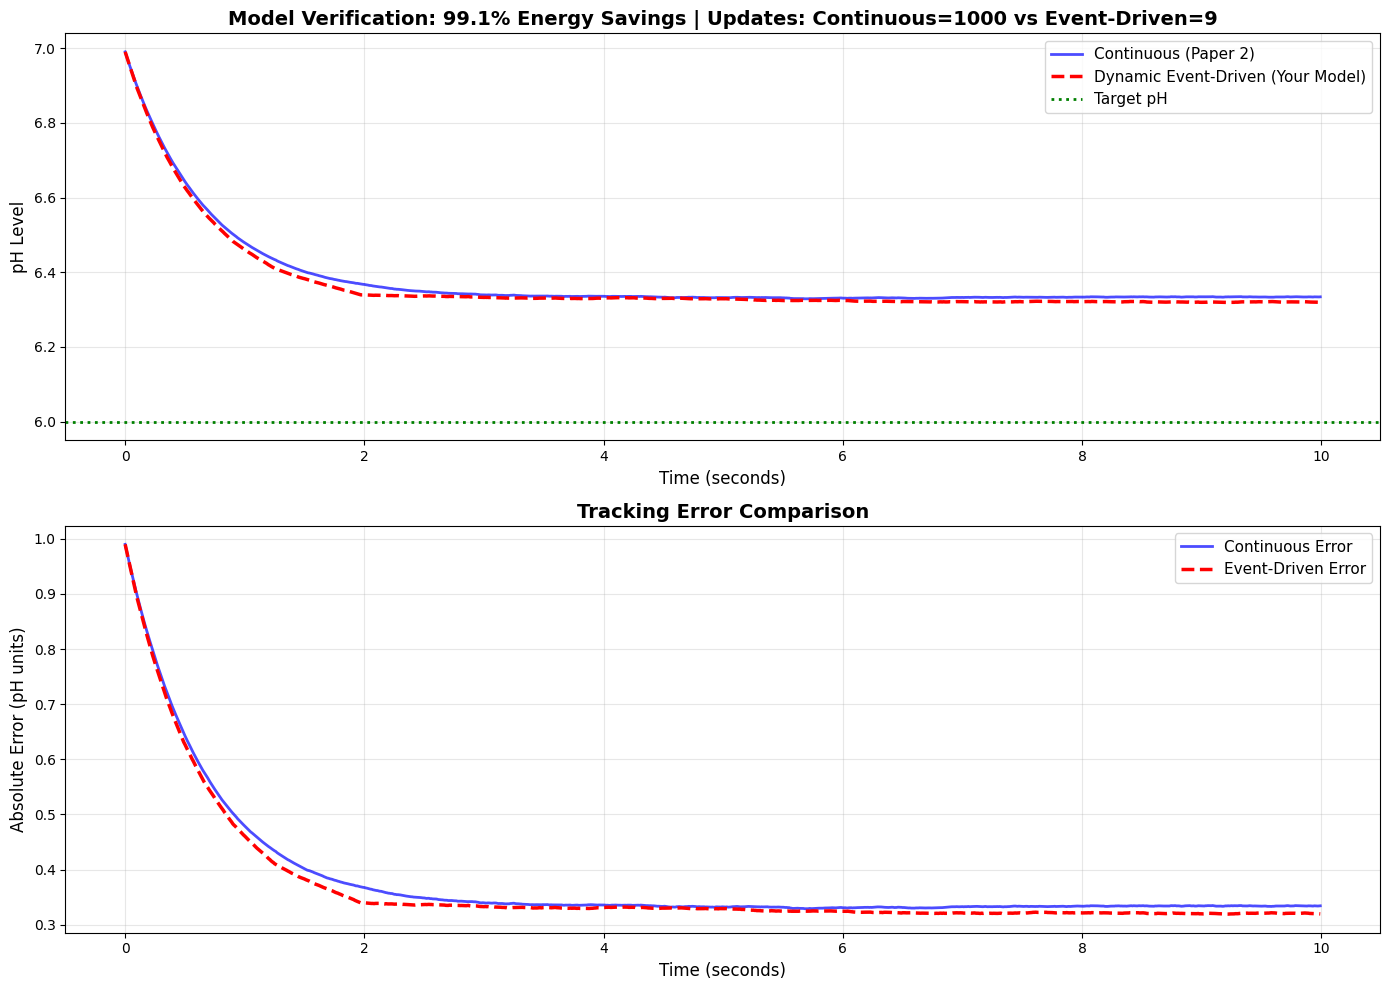

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# --- 1. THE VIRTUAL BIO-DEVICE (The Plant) ---
# Simulates a proton pump changing pH.
# It has "System Noise" (biological chaos) and "Decay" (drift).
class BioDevice:
    def __init__(self):
        self.state = 7.0  # Initial pH (Neutral)
        self.noise_level = 0.02

    def step(self, control_input, dt):
        # Physics: pH changes based on Input Voltage + Natural Decay + Random Noise
        # Equation: dx/dt = -0.5*(x - 7.0) + 2.0*u + noise

        natural_decay = -0.5 * (self.state - 7.0)  # Tries to go back to 7.0
        effectiveness = 2.0 * control_input        # The Pump's power
        noise = np.random.normal(0, self.noise_level)

        d_state = (natural_decay + effectiveness + noise) * dt
        self.state += d_state
        return self.state


# --- 2. THE DYNAMIC EVENT-TRIGGER (Your Innovation) ---
class DynamicTrigger:
    def __init__(self, alpha=0.01, beta=5.0):
        """
        Initialize the Dynamic Event-Trigger
        alpha: Sensitivity (smaller = more sensitive = more wake-ups)
        beta: Patience decay rate (larger = loses patience faster = more wake-ups)
        """
        self.gamma = 1.0  # Internal "Patience" variable
        self.alpha = alpha
        self.beta = beta
        self.last_sent_state = None
        self.event_log = []  # Track when events happen

    def check(self, current_state, error, dt, time_step):
        """
        Check if we should wake up the controller
        Returns: (should_wake_up, why_triggered)
        """
        # If first run, always update
        if self.last_sent_state is None:
            self.last_sent_state = current_state
            self.event_log.append((time_step, "Initial"))
            return True

        # Measurement Error (gap between reality and what controller "remembers")
        measure_error = current_state - self.last_sent_state

        # AGGRESSIVE Cost Function (Fixed Version)
        # Cost is HIGH (positive) when system is calm
        # Cost becomes NEGATIVE when error gap grows (System is drifting!)
        tolerance = 0.005  # Very tight tolerance (0.5% change)

        # How bad is the drift?
        drift_penalty = measure_error**2

        # Cost: If drift exceeds tolerance, it's negative (BAD, wake up!)
        C = tolerance - drift_penalty

        # Dynamic Variable Update (Eq. 12 from Paper 1)
        # d_gamma/dt = -beta * gamma + C
        d_gamma = (-self.beta * self.gamma + C) * dt
        self.gamma += d_gamma

        # Ensure gamma doesn't go negative (clip it)
        self.gamma = max(self.gamma, 0.001)

        # Trigger Rule (Eq. 11 from Paper 1)
        # Wake up when: alpha * gamma + C <= 0
        threshold = self.alpha * self.gamma + C

        if threshold <= 0:
            self.last_sent_state = current_state
            self.event_log.append((time_step, f"Threshold={threshold:.4f}"))
            return True  # WAKE UP

        return False  # SLEEP


# --- 3. RUNNING THE TEST ---
def run_comparison():
    dt = 0.01
    time_steps = 1000
    target_pH = 6.0  # We want to make it acidic

    # Create two identical bio-devices
    plant_continuous = BioDevice()
    plant_event = BioDevice()

    # Create the trigger with the corrected parameters
    trigger = DynamicTrigger(alpha=0.01, beta=5.0)

    # Storage for data
    hist_cont = []
    hist_event = []
    hist_time = []
    updates_cont = 0
    updates_event = 0

    # Initial Control inputs
    u_cont = 0
    u_event = 0

    print("Running Simulation...")
    print(f"Parameters: alpha={trigger.alpha}, beta={trigger.beta}")

    for i in range(time_steps):
        time_step = i * dt
        hist_time.append(time_step)

        # --- A. Continuous Controller (Paper 2 style) ---
        # Runs EVERY loop
        err_c = target_pH - plant_continuous.state
        u_cont = 0.5 * err_c  # Simple P-Controller
        plant_continuous.step(u_cont, dt)
        updates_cont += 1
        hist_cont.append(plant_continuous.state)

        # --- B. Event-Driven Controller (Your Style) ---
        # 1. Check if we need to wake up
        err_e = target_pH - plant_event.state
        wake_up = trigger.check(plant_event.state, err_e, dt, i)

        if wake_up:
            # Calculate NEW control only if woken up
            u_event = 0.5 * err_e
            updates_event += 1
        else:
            # Otherwise, hold the OLD control (Sleep)
            pass

        plant_event.step(u_event, dt)
        hist_event.append(plant_event.state)

    # --- 4. RESULTS ---
    print("\n" + "="*50)
    print("--- TEST RESULTS ---")
    print("="*50)
    print(f"Total Time Steps: {time_steps}")
    print(f"Total Time Duration: {time_steps * dt:.1f} seconds")
    print(f"\nContinuous Updates: {updates_cont}")
    print(f"Event-Driven Updates: {updates_event}")

    savings = (1 - updates_event/updates_cont) * 100
    print(f"\n✓ COMPUTATION SAVED: {savings:.1f}%")

    # Calculate final error
    final_err_cont = abs(hist_cont[-1] - target_pH)
    final_err_event = abs(hist_event[-1] - target_pH)

    print(f"\nFinal Tracking Error (Continuous): {final_err_cont:.4f} pH units")
    print(f"Final Tracking Error (Event-Driven): {final_err_event:.4f} pH units")

    # Calculate steady-state error
    steady_err_cont = np.mean(np.abs(np.array(hist_cont[800:]) - target_pH))
    steady_err_event = np.mean(np.abs(np.array(hist_event[800:]) - target_pH))

    print(f"\nSteady-State Error (Continuous): {steady_err_cont:.4f} pH units")
    print(f"Steady-State Error (Event-Driven): {steady_err_event:.4f} pH units")

    print(f"\nEvent Times (first 10): {trigger.event_log[:10]}")
    print("="*50)

    # --- 5. PLOT ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Main comparison plot
    ax1.plot(hist_time, hist_cont, 'b-', label='Continuous (Paper 2)', alpha=0.7, linewidth=2)
    ax1.plot(hist_time, hist_event, 'r--', label='Dynamic Event-Driven (Your Model)', linewidth=2.5)
    ax1.axhline(target_pH, color='g', linestyle=':', linewidth=2, label='Target pH')
    ax1.set_title(f"Model Verification: {savings:.1f}% Energy Savings | Updates: Continuous={updates_cont} vs Event-Driven={updates_event}",
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel("Time (seconds)", fontsize=12)
    ax1.set_ylabel("pH Level", fontsize=12)
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3)

    # Error comparison plot
    error_cont = np.abs(np.array(hist_cont) - target_pH)
    error_event = np.abs(np.array(hist_event) - target_pH)

    ax2.plot(hist_time, error_cont, 'b-', label='Continuous Error', alpha=0.7, linewidth=2)
    ax2.plot(hist_time, error_event, 'r--', label='Event-Driven Error', linewidth=2.5)
    ax2.set_title("Tracking Error Comparison", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Time (seconds)", fontsize=12)
    ax2.set_ylabel("Absolute Error (pH units)", fontsize=12)
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# --- 6. RUN THE SIMULATION ---
if __name__ == "__main__":
    run_comparison()


Continuous updates: 1000
Event-driven updates: 9
Computation saved: 99.1%


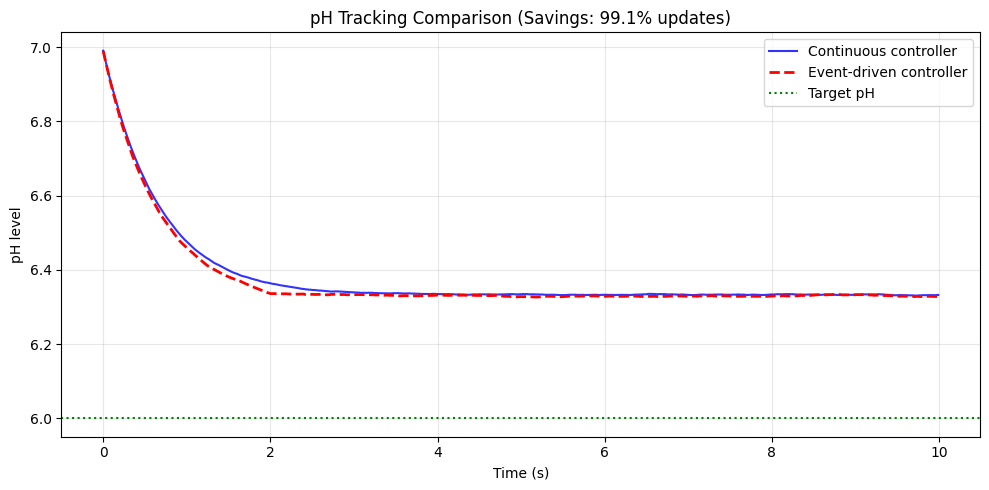

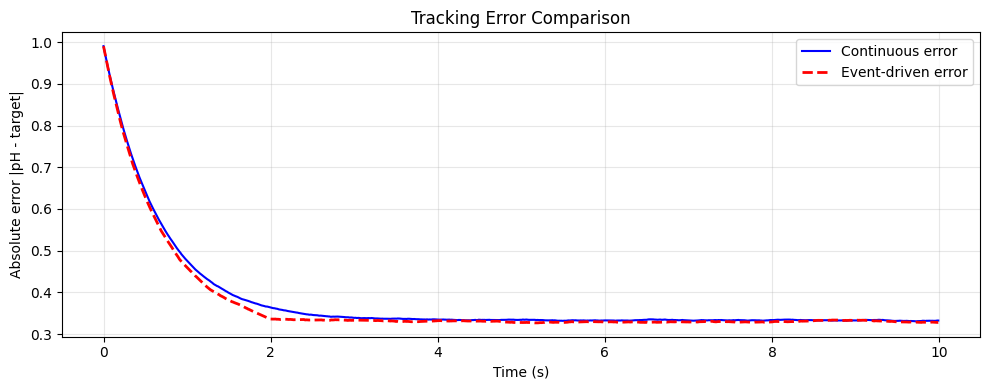

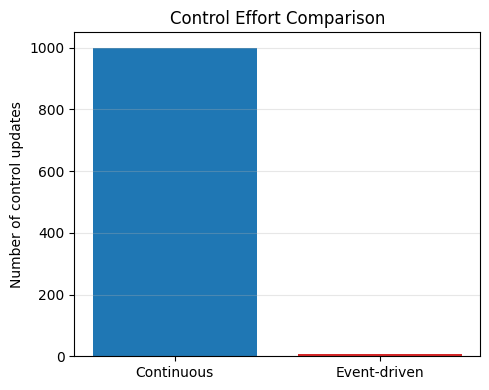

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. PLANT MODEL (BIO-DEVICE) ----------
class BioDevice:
    def __init__(self, init_pH=7.0, noise_level=0.02):
        self.state = init_pH       # Initial pH
        self.noise_level = noise_level

    def step(self, u, dt):
        """
        Simple nonlinear-ish pH dynamics:
        dx/dt = -0.5*(x - 7.0) + 2*u + noise
        """
        natural_decay = -0.5 * (self.state - 7.0)
        effectiveness = 2.0 * u
        noise = np.random.normal(0, self.noise_level)
        d_state = (natural_decay + effectiveness + noise) * dt
        self.state += d_state
        return self.state

# ---------- 2. DYNAMIC EVENT TRIGGER ----------
class DynamicTrigger:
    def __init__(self, alpha=0.01, beta=5.0, tol=0.005):
        self.gamma = 1.0
        self.alpha = alpha
        self.beta = beta
        self.tol = tol
        self.last_sent_state = None
        self.event_indices = []    # store time index when events occur

    def check(self, x_curr, dt, idx):
        """
        Returns True if a new control update is needed (event),
        otherwise False (hold previous control).
        """
        if self.last_sent_state is None:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True

        # measurement/hold error
        e_m = x_curr - self.last_sent_state

        # aggressive cost: positive when drift small, negative when drift large
        C = self.tol - (e_m ** 2)

        # dynamic variable update
        d_gamma = (-self.beta * self.gamma + C) * dt
        self.gamma += d_gamma
        self.gamma = max(self.gamma, 1e-3)

        # triggering condition
        threshold = self.alpha * self.gamma + C
        if threshold <= 0:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True
        return False

# ---------- 3. SIMULATION & COMPARISON ----------
def simulate_and_compare():
    # simulation settings
    dt = 0.01
    N = 1000
    T = np.arange(N) * dt
    target_pH = 6.0

    # create plants
    plant_cont = BioDevice()
    plant_event = BioDevice()

    # trigger
    trigger = DynamicTrigger(alpha=0.01, beta=5.0, tol=0.005)

    # histories
    x_cont_hist = []
    x_event_hist = []
    u_cont_hist = []
    u_event_hist = []

    # counters
    updates_cont = 0
    updates_event = 0

    # initial controls
    u_cont = 0.0
    u_event = 0.0

    for k in range(N):
        # --- continuous controller (baseline) ---
        err_c = target_pH - plant_cont.state
        u_cont = 0.5 * err_c        # simple P controller
        x_c = plant_cont.step(u_cont, dt)
        x_cont_hist.append(x_c)
        u_cont_hist.append(u_cont)
        updates_cont += 1

        # --- event-driven controller (proposed) ---
        err_e = target_pH - plant_event.state
        # check trigger
        if trigger.check(plant_event.state, dt, k):
            u_event = 0.5 * err_e   # update only on event
            updates_event += 1
        x_e = plant_event.step(u_event, dt)
        x_event_hist.append(x_e)
        u_event_hist.append(u_event)

    x_cont_hist = np.array(x_cont_hist)
    x_event_hist = np.array(x_event_hist)

    # errors
    err_cont = np.abs(x_cont_hist - target_pH)
    err_event = np.abs(x_event_hist - target_pH)

    # savings
    savings = (1 - updates_event / updates_cont) * 100.0

    print("Continuous updates:", updates_cont)
    print("Event-driven updates:", updates_event)
    print(f"Computation saved: {savings:.1f}%")

    # ---------- 4. PLOTS ----------

    # (a) pH vs time
    plt.figure(figsize=(10, 5))
    plt.plot(T, x_cont_hist, 'b-', label='Continuous controller', alpha=0.8)
    plt.plot(T, x_event_hist, 'r--', label='Event-driven controller', linewidth=2)
    plt.axhline(target_pH, color='g', linestyle=':', label='Target pH')
    plt.xlabel('Time (s)')
    plt.ylabel('pH level')
    plt.title(f'pH Tracking Comparison (Savings: {savings:.1f}% updates)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # (b) absolute error vs time
    plt.figure(figsize=(10, 4))
    plt.plot(T, err_cont, 'b-', label='Continuous error')
    plt.plot(T, err_event, 'r--', label='Event-driven error', linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('Absolute error |pH - target|')
    plt.title('Tracking Error Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # (c) bar chart: number of updates
    plt.figure(figsize=(5, 4))
    methods = ['Continuous', 'Event-driven']
    updates = [updates_cont, updates_event]
    colors = ['tab:blue', 'tab:red']
    plt.bar(methods, updates, color=colors)
    plt.ylabel('Number of control updates')
    plt.title('Control Effort Comparison')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    simulate_and_compare()


Continuous updates: 1000
Event-driven updates: 9
Computation saved: 99.1%


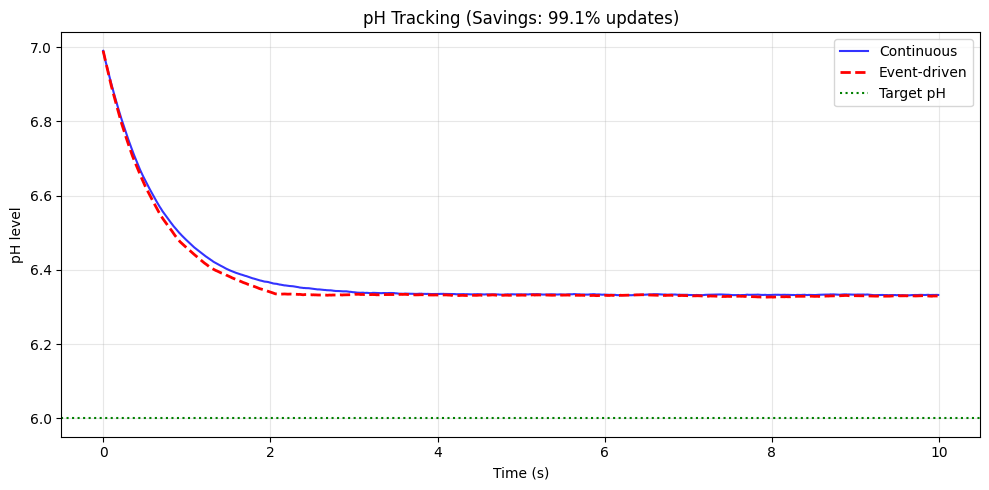

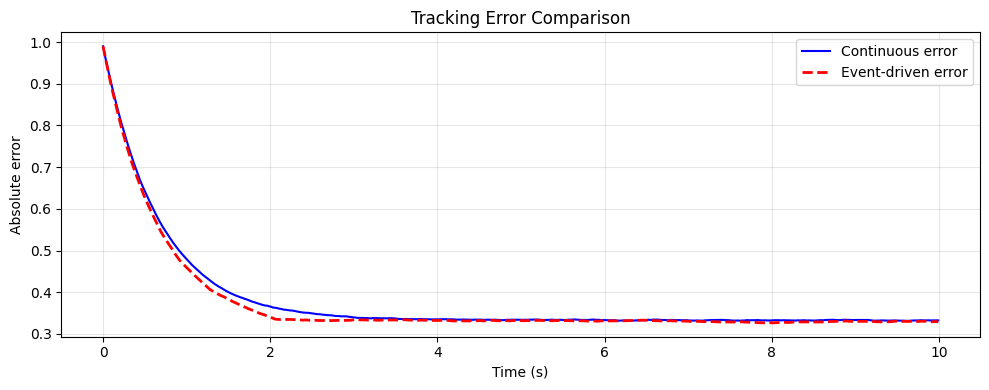

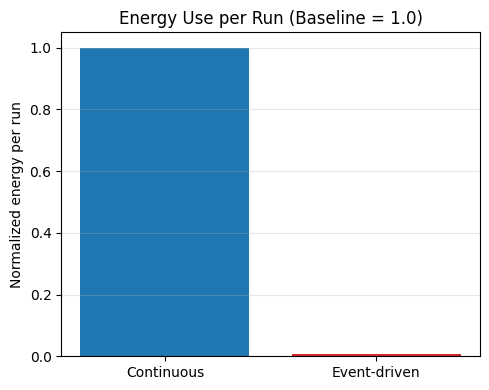

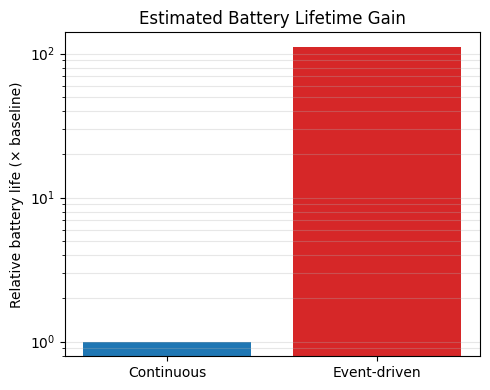

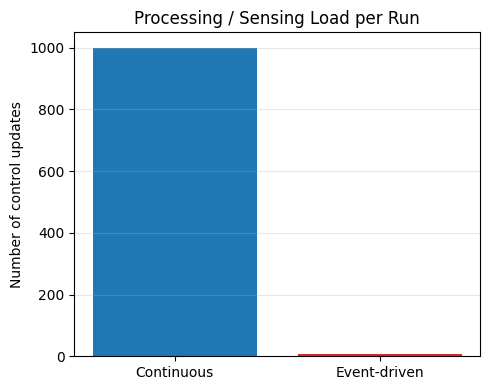

Normalized energy (event-driven): 0.0090
Relative battery life gain: 111.1×


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. PLANT MODEL ----------
class BioDevice:
    def __init__(self, init_pH=7.0, noise_level=0.02):
        self.state = init_pH
        self.noise_level = noise_level

    def step(self, u, dt):
        natural_decay = -0.5 * (self.state - 7.0)
        effectiveness = 2.0 * u
        noise = np.random.normal(0, self.noise_level)
        d_state = (natural_decay + effectiveness + noise) * dt
        self.state += d_state
        return self.state

# ---------- 2. DYNAMIC EVENT TRIGGER ----------
class DynamicTrigger:
    def __init__(self, alpha=0.01, beta=5.0, tol=0.005):
        self.gamma = 1.0
        self.alpha = alpha
        self.beta = beta
        self.tol = tol
        self.last_sent_state = None
        self.event_indices = []

    def check(self, x_curr, dt, idx):
        if self.last_sent_state is None:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True

        e_m = x_curr - self.last_sent_state
        C = self.tol - (e_m ** 2)
        d_gamma = (-self.beta * self.gamma + C) * dt
        self.gamma += d_gamma
        self.gamma = max(self.gamma, 1e-3)
        threshold = self.alpha * self.gamma + C
        if threshold <= 0:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True
        return False

# ---------- 3. RESOURCE IMPACT PLOTS ----------
def plot_resource_impacts(updates_cont, updates_event):
    energy_cont = 1.0
    energy_event = updates_event / updates_cont

    R = updates_cont / updates_event
    life_cont = 1.0
    life_event = R

    load_cont = updates_cont
    load_event = updates_event

    methods = ['Continuous', 'Event-driven']

    # Energy per run
    plt.figure(figsize=(5,4))
    plt.bar(methods, [energy_cont, energy_event],
            color=['tab:blue','tab:red'])
    plt.ylabel('Normalized energy per run')
    plt.title('Energy Use per Run (Baseline = 1.0)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Relative battery life (log scale)
    plt.figure(figsize=(5,4))
    plt.bar(methods, [life_cont, life_event],
            color=['tab:blue','tab:red'])
    plt.ylabel('Relative battery life (× baseline)')
    plt.title('Estimated Battery Lifetime Gain')
    plt.yscale('log')
    plt.grid(axis='y', alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

    # Processing / sensing load
    plt.figure(figsize=(5,4))
    plt.bar(methods, [load_cont, load_event],
            color=['tab:blue','tab:red'])
    plt.ylabel('Number of control updates')
    plt.title('Processing / Sensing Load per Run')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Normalized energy (event-driven): {energy_event:.4f}")
    print(f"Relative battery life gain: {life_event:.1f}×")

# ---------- 4. SIMULATION & COMPARISON ----------
def simulate_and_compare():
    dt = 0.01
    N = 1000
    T = np.arange(N) * dt
    target_pH = 6.0

    plant_cont = BioDevice()
    plant_event = BioDevice()
    trigger = DynamicTrigger(alpha=0.01, beta=5.0, tol=0.005)

    x_cont_hist, x_event_hist = [], []
    u_cont_hist, u_event_hist = [], []
    updates_cont = 0
    updates_event = 0
    u_cont = 0.0
    u_event = 0.0

    for k in range(N):
        # continuous
        err_c = target_pH - plant_cont.state
        u_cont = 0.5 * err_c
        x_c = plant_cont.step(u_cont, dt)
        x_cont_hist.append(x_c)
        u_cont_hist.append(u_cont)
        updates_cont += 1

        # event-driven
        err_e = target_pH - plant_event.state
        if trigger.check(plant_event.state, dt, k):
            u_event = 0.5 * err_e
            updates_event += 1
        x_e = plant_event.step(u_event, dt)
        x_event_hist.append(x_e)
        u_event_hist.append(u_event)

    x_cont_hist = np.array(x_cont_hist)
    x_event_hist = np.array(x_event_hist)
    err_cont = np.abs(x_cont_hist - target_pH)
    err_event = np.abs(x_event_hist - target_pH)
    savings = (1 - updates_event / updates_cont) * 100.0

    print("Continuous updates:", updates_cont)
    print("Event-driven updates:", updates_event)
    print(f"Computation saved: {savings:.1f}%")

    # --- existing accuracy plots (optional, can skip if you already have them) ---
    plt.figure(figsize=(10,5))
    plt.plot(T, x_cont_hist, 'b-', label='Continuous', alpha=0.8)
    plt.plot(T, x_event_hist, 'r--', label='Event-driven', linewidth=2)
    plt.axhline(target_pH, color='g', linestyle=':', label='Target pH')
    plt.xlabel('Time (s)')
    plt.ylabel('pH level')
    plt.title(f'pH Tracking (Savings: {savings:.1f}% updates)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(T, err_cont, 'b-', label='Continuous error')
    plt.plot(T, err_event, 'r--', label='Event-driven error', linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('Absolute error')
    plt.title('Tracking Error Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- NEW: resource impact graphs ---
    plot_resource_impacts(updates_cont, updates_event)

# ---------- 5. RUN ----------
simulate_and_compare()


Continuous updates: 1000
Event-driven updates: 9
Computation saved: 99.1%


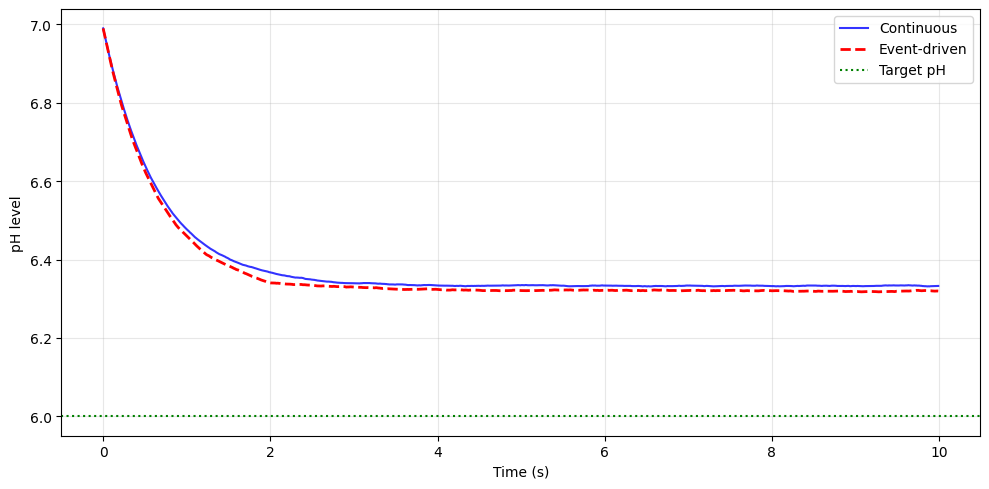

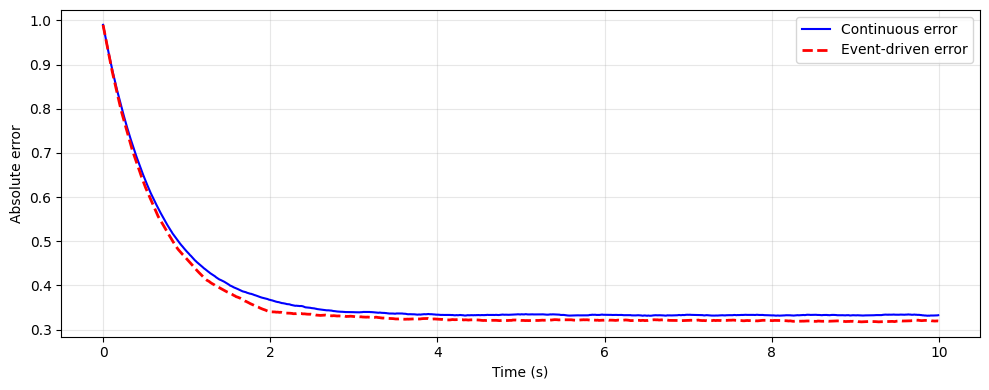

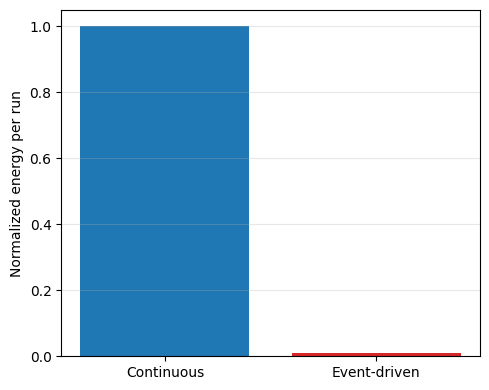

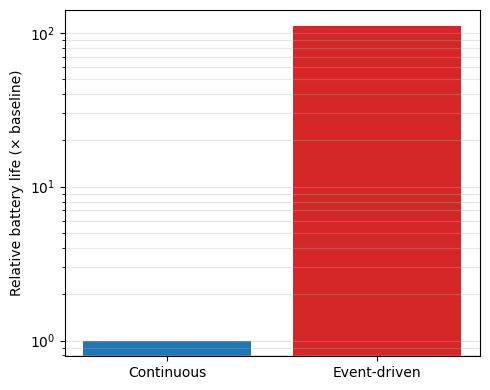

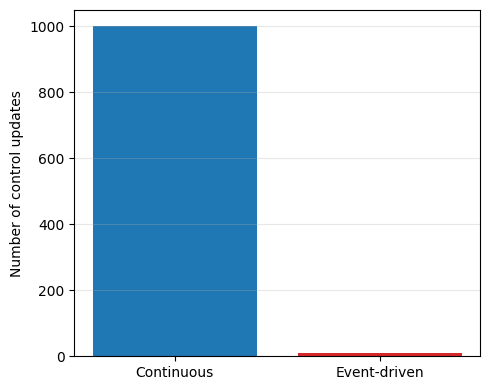

Normalized energy (event-driven): 0.0090
Relative battery life gain: 111.1×


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ---------- 1. PLANT MODEL ----------
class BioDevice:
    def __init__(self, init_pH=7.0, noise_level=0.02):
        self.state = init_pH
        self.noise_level = noise_level

    def step(self, u, dt):
        natural_decay = -0.5 * (self.state - 7.0)
        effectiveness = 2.0 * u
        noise = np.random.normal(0, self.noise_level)
        d_state = (natural_decay + effectiveness + noise) * dt
        self.state += d_state
        return self.state


# ---------- 2. DYNAMIC EVENT TRIGGER ----------
class DynamicTrigger:
    def __init__(self, alpha=0.01, beta=5.0, tol=0.005):
        self.gamma = 1.0
        self.alpha = alpha
        self.beta = beta
        self.tol = tol
        self.last_sent_state = None
        self.event_indices = []

    def check(self, x_curr, dt, idx):
        if self.last_sent_state is None:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True

        e_m = x_curr - self.last_sent_state
        C = self.tol - (e_m ** 2)
        d_gamma = (-self.beta * self.gamma + C) * dt
        self.gamma += d_gamma
        self.gamma = max(self.gamma, 1e-3)
        threshold = self.alpha * self.gamma + C
        if threshold <= 0:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True
        return False


# ---------- 3. RESOURCE IMPACT PLOTS ----------
def plot_resource_impacts(updates_cont, updates_event):
    energy_cont = 1.0
    energy_event = updates_event / updates_cont

    R = updates_cont / updates_event
    life_cont = 1.0
    life_event = R

    load_cont = updates_cont
    load_event = updates_event

    methods = ['Continuous', 'Event-driven']

    # Energy per run
    plt.figure(figsize=(5,4))
    plt.bar(methods, [energy_cont, energy_event],
            color=['tab:blue','tab:red'])
    plt.ylabel('Normalized energy per run')
    # plt.title('Energy Use per Run (Baseline = 1.0)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('resource_energy.pdf', bbox_inches='tight', dpi=300)

    plt.show()

    # Relative battery life (log scale)
    plt.figure(figsize=(5,4))
    plt.bar(methods, [life_cont, life_event],
            color=['tab:blue','tab:red'])
    plt.ylabel('Relative battery life (× baseline)')
    # plt.title('Estimated Battery Lifetime Gain')
    plt.yscale('log')
    plt.grid(axis='y', alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig('resource_battery.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Processing / sensing load
    plt.figure(figsize=(5,4))
    plt.bar(methods, [load_cont, load_event],
            color=['tab:blue','tab:red'])
    plt.ylabel('Number of control updates')
    # plt.title('Processing / Sensing Load per Run')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('resource_updates.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    print(f"Normalized energy (event-driven): {energy_event:.4f}")
    print(f"Relative battery life gain: {life_event:.1f}×")


# ---------- 4. SIMULATION & COMPARISON ----------
def simulate_and_compare():
    dt = 0.01
    N = 1000
    T = np.arange(N) * dt
    target_pH = 6.0

    plant_cont = BioDevice()
    plant_event = BioDevice()
    trigger = DynamicTrigger(alpha=0.01, beta=5.0, tol=0.005)

    x_cont_hist, x_event_hist = [], []
    u_cont_hist, u_event_hist = [], []
    updates_cont = 0
    updates_event = 0
    u_cont = 0.0
    u_event = 0.0

    for k in range(N):
        # continuous
        err_c = target_pH - plant_cont.state
        u_cont = 0.5 * err_c
        x_c = plant_cont.step(u_cont, dt)
        x_cont_hist.append(x_c)
        u_cont_hist.append(u_cont)
        updates_cont += 1

        # event-driven
        err_e = target_pH - plant_event.state
        if trigger.check(plant_event.state, dt, k):
            u_event = 0.5 * err_e
            updates_event += 1
        x_e = plant_event.step(u_event, dt)
        x_event_hist.append(x_e)
        u_event_hist.append(u_event)

    x_cont_hist = np.array(x_cont_hist)
    x_event_hist = np.array(x_event_hist)
    err_cont = np.abs(x_cont_hist - target_pH)
    err_event = np.abs(x_event_hist - target_pH)
    savings = (1 - updates_event / updates_cont) * 100.0

    print("Continuous updates:", updates_cont)
    print("Event-driven updates:", updates_event)
    print(f"Computation saved: {savings:.1f}%")

    # --- pH tracking plot ---
    plt.figure(figsize=(10,5))
    plt.plot(T, x_cont_hist, 'b-', label='Continuous', alpha=0.8)
    plt.plot(T, x_event_hist, 'r--', label='Event-driven', linewidth=2)
    plt.axhline(target_pH, color='g', linestyle=':', label='Target pH')
    plt.xlabel('Time (s)')
    plt.ylabel('pH level')
    # plt.title(f'pH Tracking (Savings: {savings:.1f}% updates)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('ph_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- error plot ---
    plt.figure(figsize=(10,4))
    plt.plot(T, err_cont, 'b-', label='Continuous error')
    plt.plot(T, err_event, 'r--', label='Event-driven error', linewidth=2)
    plt.xlabel('Time (s)')
    plt.ylabel('Absolute error')
    # plt.title('Tracking Error Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('error_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- resource impact graphs ---
    plot_resource_impacts(updates_cont, updates_event)


# ---------- 5. RUN ----------
simulate_and_compare()


Continuous updates: 1000
Event-driven updates: 9
Computation saved: 99.1%


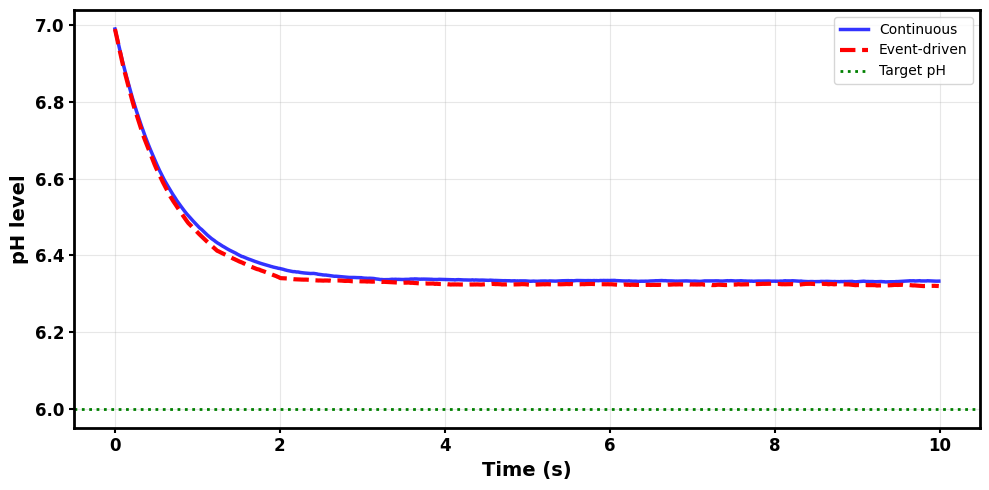

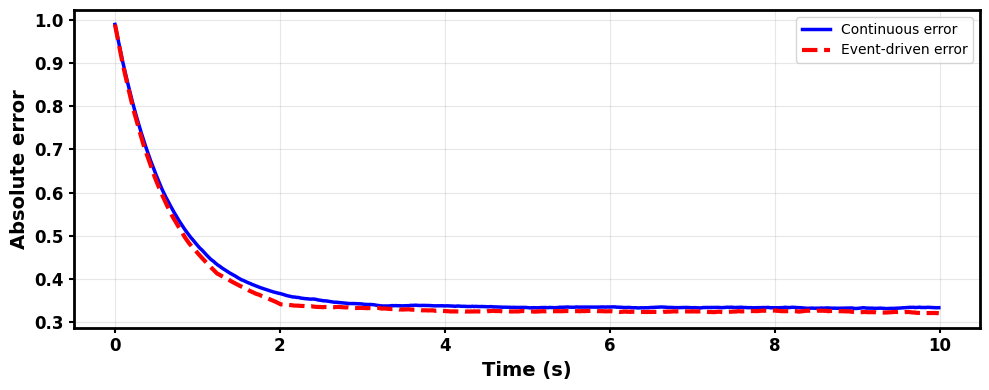

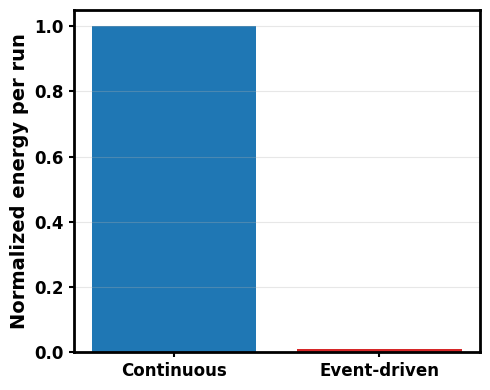

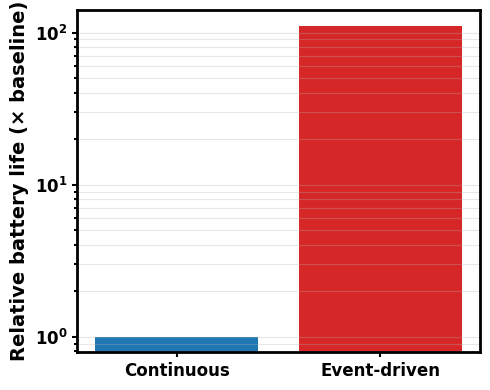

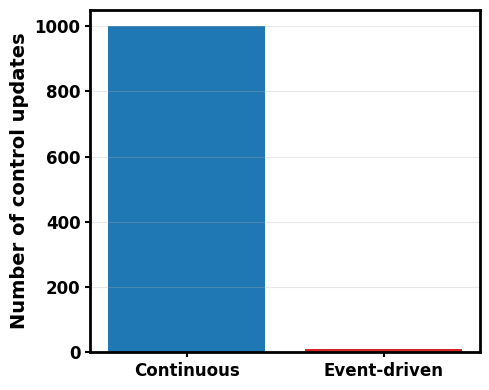

Normalized energy (event-driven): 0.0090
Relative battery life gain: 111.1×


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. PLANT MODEL ----------
class BioDevice:
    def __init__(self, init_pH=7.0, noise_level=0.02):
        self.state = init_pH
        self.noise_level = noise_level

    def step(self, u, dt):
        natural_decay = -0.5 * (self.state - 7.0)
        effectiveness = 2.0 * u
        noise = np.random.normal(0, self.noise_level)
        d_state = (natural_decay + effectiveness + noise) * dt
        self.state += d_state
        return self.state


# ---------- 2. DYNAMIC EVENT TRIGGER ----------
class DynamicTrigger:
    def __init__(self, alpha=0.01, beta=5.0, tol=0.005):
        self.gamma = 1.0
        self.alpha = alpha
        self.beta = beta
        self.tol = tol
        self.last_sent_state = None
        self.event_indices = []

    def check(self, x_curr, dt, idx):
        if self.last_sent_state is None:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True

        e_m = x_curr - self.last_sent_state
        C = self.tol - (e_m ** 2)
        d_gamma = (-self.beta * self.gamma + C) * dt
        self.gamma += d_gamma
        self.gamma = max(self.gamma, 1e-3)
        threshold = self.alpha * self.gamma + C
        if threshold <= 0:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True
        return False


# ---------- COMMON STYLE HELPER ----------
def make_axes_bold(ax):
    # Thicken border
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Thicker ticks (lines)
    ax.tick_params(axis='both', which='both', width=1.5, labelsize=12)

    # Bold tick labels (numbers)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    # Bold, larger axis labels ("Time (s)", "pH level", etc.)
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
    ax.xaxis.label.set_weight('bold')
    ax.yaxis.label.set_weight('bold')



# ---------- 3. RESOURCE IMPACT PLOTS ----------
def plot_resource_impacts(updates_cont, updates_event):
    energy_cont = 1.0
    energy_event = updates_event / updates_cont

    R = updates_cont / updates_event
    life_cont = 1.0
    life_event = R

    load_cont = updates_cont
    load_event = updates_event

    methods = ['Continuous', 'Event-driven']

    # Energy per run
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(methods, [energy_cont, energy_event],
           color=['tab:blue','tab:red'])
    ax.set_ylabel('Normalized energy per run')
    ax.grid(axis='y', alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_energy.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Relative battery life (log scale)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(methods, [life_cont, life_event],
           color=['tab:blue','tab:red'])
    ax.set_ylabel('Relative battery life (× baseline)')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both')
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_battery.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Processing / sensing load
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(methods, [load_cont, load_event],
           color=['tab:blue','tab:red'])
    ax.set_ylabel('Number of control updates')
    ax.grid(axis='y', alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_updates.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    print(f"Normalized energy (event-driven): {energy_event:.4f}")
    print(f"Relative battery life gain: {life_event:.1f}×")


# ---------- 4. SIMULATION & COMPARISON ----------
def simulate_and_compare():
    dt = 0.01
    N = 1000
    T = np.arange(N) * dt
    target_pH = 6.0

    plant_cont = BioDevice()
    plant_event = BioDevice()
    trigger = DynamicTrigger(alpha=0.01, beta=5.0, tol=0.005)

    x_cont_hist, x_event_hist = [], []
    u_cont_hist, u_event_hist = [], []
    updates_cont = 0
    updates_event = 0
    u_cont = 0.0
    u_event = 0.0

    for k in range(N):
        # continuous
        err_c = target_pH - plant_cont.state
        u_cont = 0.5 * err_c
        x_c = plant_cont.step(u_cont, dt)
        x_cont_hist.append(x_c)
        u_cont_hist.append(u_cont)
        updates_cont += 1

        # event-driven
        err_e = target_pH - plant_event.state
        if trigger.check(plant_event.state, dt, k):
            u_event = 0.5 * err_e
            updates_event += 1
        x_e = plant_event.step(u_event, dt)
        x_event_hist.append(x_e)
        u_event_hist.append(u_event)

    x_cont_hist = np.array(x_cont_hist)
    x_event_hist = np.array(x_event_hist)
    err_cont = np.abs(x_cont_hist - target_pH)
    err_event = np.abs(x_event_hist - target_pH)
    savings = (1 - updates_event / updates_cont) * 100.0

    print("Continuous updates:", updates_cont)
    print("Event-driven updates:", updates_event)
    print(f"Computation saved: {savings:.1f}%")

    # --- pH tracking plot ---
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(T, x_cont_hist, 'b-', label='Continuous', alpha=0.8, linewidth=2.5)
    ax.plot(T, x_event_hist, 'r--', label='Event-driven', linewidth=3)
    ax.axhline(target_pH, color='g', linestyle=':', label='Target pH', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('pH level')
    ax.legend()
    ax.grid(True, alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('ph_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- error plot ---
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(T, err_cont, 'b-', label='Continuous error', linewidth=2.5)
    ax.plot(T, err_event, 'r--', label='Event-driven error', linewidth=3)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Absolute error')
    ax.legend()
    ax.grid(True, alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('error_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- resource impact graphs ---
    plot_resource_impacts(updates_cont, updates_event)


# ---------- 5. RUN ----------
simulate_and_compare()


Continuous updates: 1000
Time-triggered updates: 200
Event-driven updates: 9


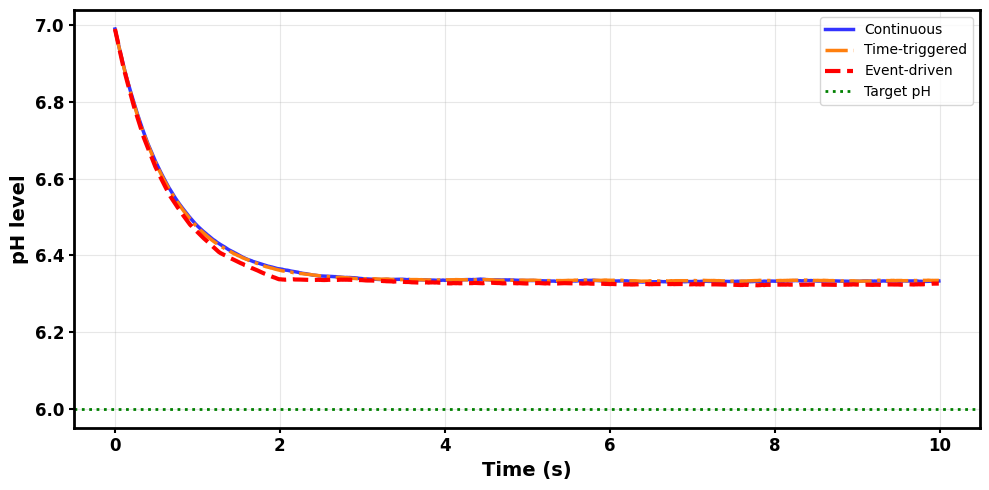

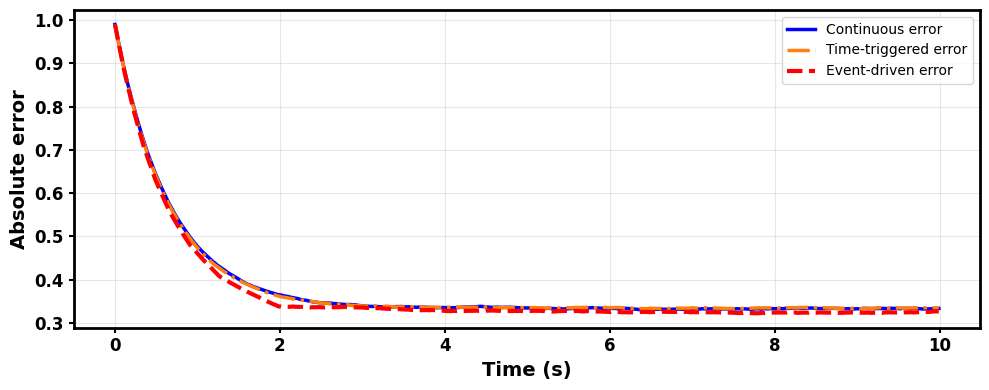

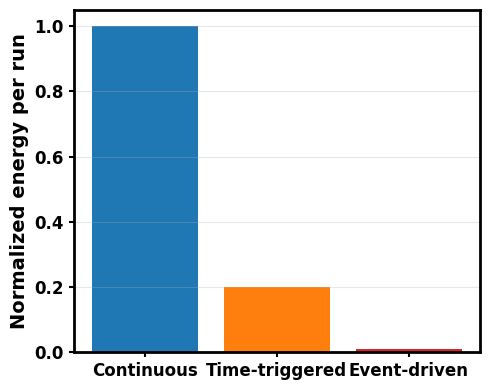

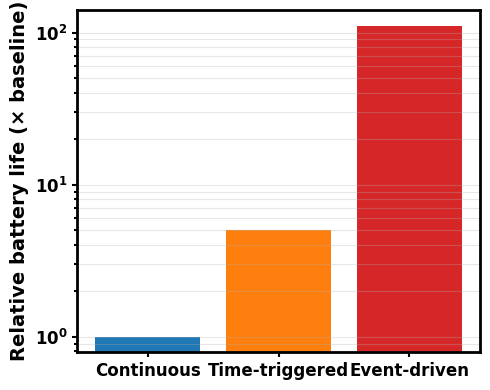

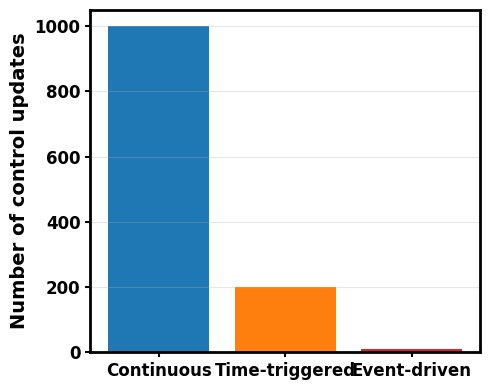

Normalized energy (time-triggered): 0.2000
Normalized energy (event-driven):  0.0090
Relative battery life gain (time-triggered): 5.0×
Relative battery life gain (event-driven):  111.1×


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. PLANT MODEL ----------
class BioDevice:
    def __init__(self, init_pH=7.0, noise_level=0.02):
        self.state = init_pH
        self.noise_level = noise_level

    def step(self, u, dt):
        natural_decay = -0.5 * (self.state - 7.0)
        effectiveness = 2.0 * u
        noise = np.random.normal(0, self.noise_level)
        d_state = (natural_decay + effectiveness + noise) * dt
        self.state += d_state
        return self.state


# ---------- 2. DYNAMIC EVENT TRIGGER ----------
class DynamicTrigger:
    def __init__(self, alpha=0.01, beta=5.0, tol=0.005):
        self.gamma = 1.0
        self.alpha = alpha
        self.beta = beta
        self.tol = tol
        self.last_sent_state = None
        self.event_indices = []

    def check(self, x_curr, dt, idx):
        if self.last_sent_state is None:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True

        e_m = x_curr - self.last_sent_state
        C = self.tol - (e_m ** 2)
        d_gamma = (-self.beta * self.gamma + C) * dt
        self.gamma += d_gamma
        self.gamma = max(self.gamma, 1e-3)
        threshold = self.alpha * self.gamma + C
        if threshold <= 0:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True
        return False


# ---------- COMMON STYLE HELPER ----------
def make_axes_bold(ax):
    # Thicken border
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Thicker ticks (lines)
    ax.tick_params(axis='both', which='both', width=1.5, labelsize=12)

    # Bold tick labels (numbers)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    # Bold, larger axis labels ("Time (s)", "pH level", etc.)
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
    ax.xaxis.label.set_weight('bold')
    ax.yaxis.label.set_weight('bold')

# ---------- 3. RESOURCE IMPACT PLOTS ----------
def plot_resource_impacts(updates_cont, updates_event, updates_time):
    # Normalize everything to continuous = 1.0
    energy_cont = 1.0
    energy_event = updates_event / updates_cont
    energy_time  = updates_time  / updates_cont

    R_event = updates_cont / updates_event
    R_time  = updates_cont / updates_time
    life_cont  = 1.0
    life_event = R_event
    life_time  = R_time

    load_cont  = updates_cont
    load_event = updates_event
    load_time  = updates_time

    methods = ['Continuous', 'Time-triggered', 'Event-driven']

    # Energy per run
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(methods,
           [energy_cont, energy_time, energy_event],
           color=['tab:blue','tab:orange','tab:red'])
    ax.set_ylabel('Normalized energy per run')
    ax.grid(axis='y', alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_energy.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Relative battery life (log scale)
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(methods,
           [life_cont, life_time, life_event],
           color=['tab:blue','tab:orange','tab:red'])
    ax.set_ylabel('Relative battery life (× baseline)')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both')
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_battery.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Processing / sensing load
    fig, ax = plt.subplots(figsize=(5,4))
    ax.bar(methods,
           [load_cont, load_time, load_event],
           color=['tab:blue','tab:orange','tab:red'])
    ax.set_ylabel('Number of control updates')
    ax.grid(axis='y', alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_updates.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    print(f"Normalized energy (time-triggered): {energy_time:.4f}")
    print(f"Normalized energy (event-driven):  {energy_event:.4f}")
    print(f"Relative battery life gain (time-triggered): {life_time:.1f}×")
    print(f"Relative battery life gain (event-driven):  {life_event:.1f}×")
def simulate_and_compare():
    dt = 0.01
    N = 1000
    T = np.arange(N) * dt
    target_pH = 6.0

    plant_cont  = BioDevice()
    plant_event = BioDevice()
    plant_time  = BioDevice()

    trigger = DynamicTrigger(alpha=0.01, beta=5.0, tol=0.005)

    x_cont_hist, x_event_hist, x_time_hist = [], [], []
    u_cont_hist, u_event_hist, u_time_hist = [], [], []

    updates_cont = 0
    updates_event = 0
    updates_time = 0

    u_cont = 0.0
    u_event = 0.0
    u_time = 0.0

    time_period = 5       # time-triggered: update every 5 steps

    for k in range(N):
        # continuous
        err_c = target_pH - plant_cont.state
        u_cont = 0.5 * err_c
        x_c = plant_cont.step(u_cont, dt)
        x_cont_hist.append(x_c)
        u_cont_hist.append(u_cont)
        updates_cont += 1

        # time-triggered (periodic sampling)
        if k % time_period == 0:
            err_t = target_pH - plant_time.state
            u_time = 0.5 * err_t
            updates_time += 1
        x_t = plant_time.step(u_time, dt)
        x_time_hist.append(x_t)
        u_time_hist.append(u_time)

        # event-driven
        err_e = target_pH - plant_event.state
        if trigger.check(plant_event.state, dt, k):
            u_event = 0.5 * err_e
            updates_event += 1
        x_e = plant_event.step(u_event, dt)
        x_event_hist.append(x_e)
        u_event_hist.append(u_event)

    x_cont_hist  = np.array(x_cont_hist)
    x_event_hist = np.array(x_event_hist)
    x_time_hist  = np.array(x_time_hist)

    err_cont  = np.abs(x_cont_hist  - target_pH)
    err_event = np.abs(x_event_hist - target_pH)
    err_time  = np.abs(x_time_hist  - target_pH)

    print("Continuous updates:", updates_cont)
    print("Time-triggered updates:", updates_time)
    print("Event-driven updates:", updates_event)

    # --- pH tracking plot ---
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(T, x_cont_hist,  'b-',  label='Continuous',    alpha=0.8, linewidth=2.5)
    ax.plot(T, x_time_hist,  'C1-.',label='Time-triggered',linewidth=2.5)
    ax.plot(T, x_event_hist, 'r--', label='Event-driven',  linewidth=3)
    ax.axhline(target_pH, color='g', linestyle=':', label='Target pH', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('pH level')
    ax.legend()
    ax.grid(True, alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('ph_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- error plot ---
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(T, err_cont,  'b-',  label='Continuous error',    linewidth=2.5)
    ax.plot(T, err_time,  'C1-.',label='Time-triggered error',linewidth=2.5)
    ax.plot(T, err_event, 'r--', label='Event-driven error',  linewidth=3)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Absolute error')
    ax.legend()
    ax.grid(True, alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('error_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- resource impact graphs with 3 bars ---
    plot_resource_impacts(updates_cont, updates_event, updates_time)


# ---------- 5. RUN ----------
simulate_and_compare()


Continuous updates: 1000
Time-triggered updates: 200
Event-driven updates: 9


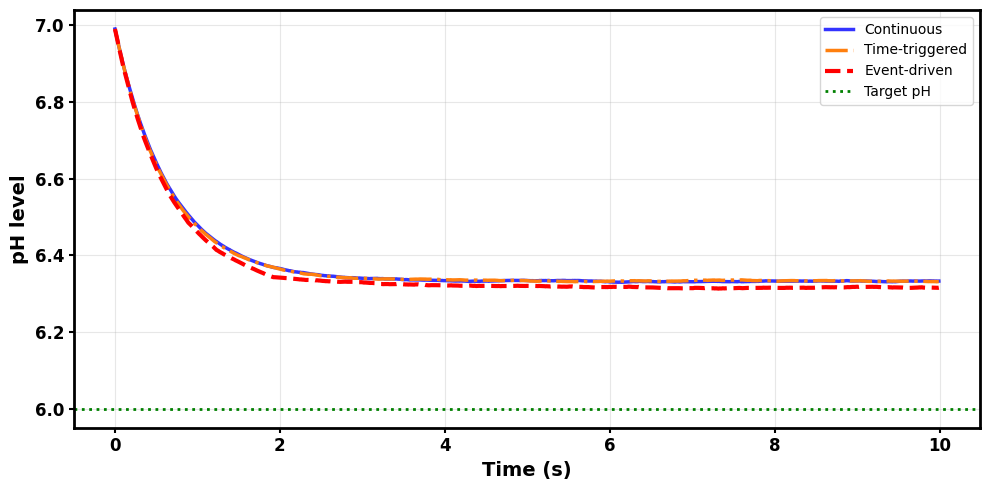

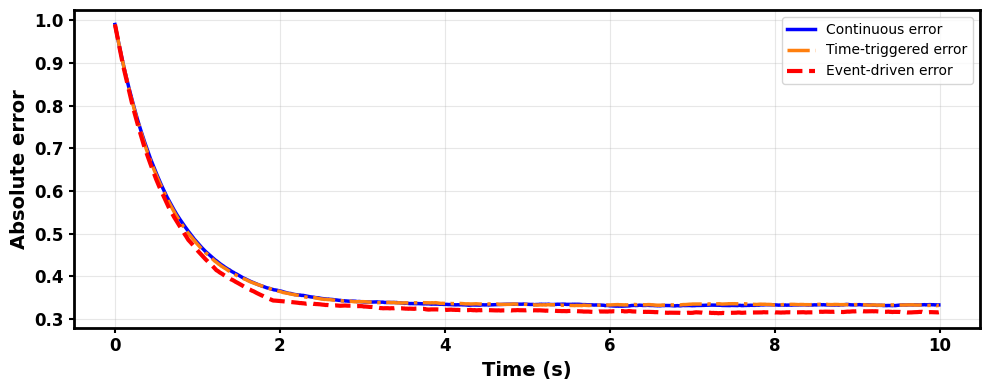

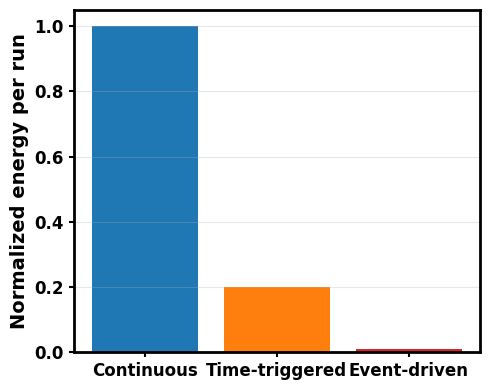

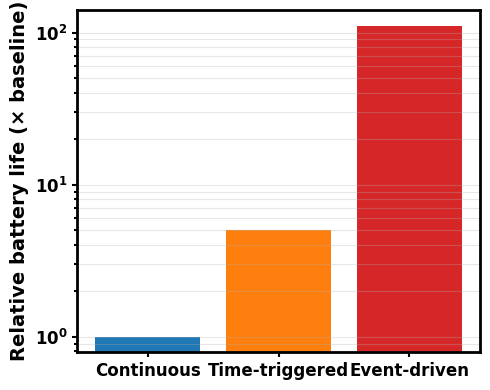

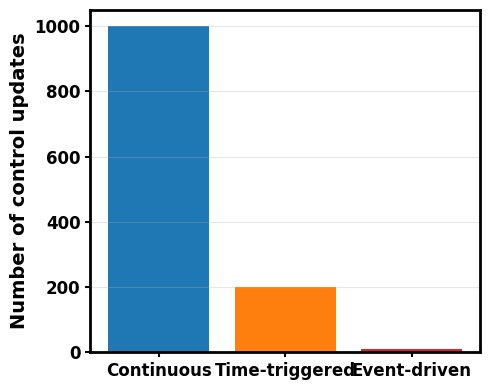

Normalized energy (time-triggered): 0.2000
Normalized energy (event-driven):  0.0090
Relative battery life gain (time-triggered): 5.0×
Relative battery life gain (event-driven):  111.1×


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ---------- 1. PLANT MODEL ----------
class BioDevice:
    def __init__(self, init_pH=7.0, noise_level=0.02):
        self.state = init_pH
        self.noise_level = noise_level

    def step(self, u, dt):
        natural_decay = -0.5 * (self.state - 7.0)
        effectiveness = 2.0 * u
        noise = np.random.normal(0, self.noise_level)
        d_state = (natural_decay + effectiveness + noise) * dt
        self.state += d_state
        return self.state


# ---------- 2. DYNAMIC EVENT TRIGGER ----------
class DynamicTrigger:
    def __init__(self, alpha=0.01, beta=5.0, tol=0.005):
        self.gamma = 1.0
        self.alpha = alpha
        self.beta = beta
        self.tol = tol
        self.last_sent_state = None
        self.event_indices = []

    def check(self, x_curr, dt, idx):
        if self.last_sent_state is None:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True

        e_m = x_curr - self.last_sent_state
        C = self.tol - (e_m ** 2)
        d_gamma = (-self.beta * self.gamma + C) * dt
        self.gamma += d_gamma
        self.gamma = max(self.gamma, 1e-3)
        threshold = self.alpha * self.gamma + C
        if threshold <= 0:
            self.last_sent_state = x_curr
            self.event_indices.append(idx)
            return True
        return False


# ---------- COMMON STYLE HELPER ----------
def make_axes_bold(ax):
    # Thicken border
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Thicker ticks (lines)
    ax.tick_params(axis='both', which='both', width=1.5, labelsize=12)

    # Bold tick labels (numbers)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    # Bold, larger axis labels ("Time (s)", "pH level", etc.)
    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
    ax.xaxis.label.set_weight('bold')
    ax.yaxis.label.set_weight('bold')


# ---------- 3. RESOURCE IMPACT PLOTS ----------
def plot_resource_impacts(updates_cont, updates_event, updates_time):
    # Normalize everything to continuous = 1.0
    energy_cont = 1.0
    energy_event = updates_event / updates_cont
    energy_time  = updates_time  / updates_cont

    R_event = updates_cont / updates_event
    R_time  = updates_cont / updates_time
    life_cont  = 1.0
    life_event = R_event
    life_time  = R_time

    load_cont  = updates_cont
    load_event = updates_event
    load_time  = updates_time

    methods = ['Continuous', 'Time-triggered', 'Event-driven']

    # Energy per run
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(methods,
           [energy_cont, energy_time, energy_event],
           color=['tab:blue', 'tab:orange', 'tab:red'])
    ax.set_ylabel('Normalized energy per run')
    ax.grid(axis='y', alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_energy.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Relative battery life (log scale)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(methods,
           [life_cont, life_time, life_event],
           color=['tab:blue', 'tab:orange', 'tab:red'])
    ax.set_ylabel('Relative battery life (× baseline)')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both')
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_battery.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Processing / sensing load
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(methods,
           [load_cont, load_time, load_event],
           color=['tab:blue', 'tab:orange', 'tab:red'])
    ax.set_ylabel('Number of control updates')
    ax.grid(axis='y', alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('resource_updates.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    print(f"Normalized energy (time-triggered): {energy_time:.4f}")
    print(f"Normalized energy (event-driven):  {energy_event:.4f}")
    print(f"Relative battery life gain (time-triggered): {life_time:.1f}×")
    print(f"Relative battery life gain (event-driven):  {life_event:.1f}×")


# ---------- 4. SIMULATION & COMPARISON ----------
def simulate_and_compare():
    dt = 0.01
    N = 1000
    T = np.arange(N) * dt
    target_pH = 6.0

    plant_cont  = BioDevice()
    plant_event = BioDevice()
    plant_time  = BioDevice()

    trigger = DynamicTrigger(alpha=0.01, beta=5.0, tol=0.005)

    x_cont_hist, x_event_hist, x_time_hist = [], [], []
    u_cont_hist, u_event_hist, u_time_hist = [], [], []

    updates_cont = 0
    updates_event = 0
    updates_time = 0

    u_cont = 0.0
    u_event = 0.0
    u_time = 0.0

    time_period = 5  # time-triggered: update every 5 steps

    for k in range(N):
        # continuous
        err_c = target_pH - plant_cont.state
        u_cont = 0.5 * err_c
        x_c = plant_cont.step(u_cont, dt)
        x_cont_hist.append(x_c)
        u_cont_hist.append(u_cont)
        updates_cont += 1

        # time-triggered (periodic sampling)
        if k % time_period == 0:
            err_t = target_pH - plant_time.state
            u_time = 0.5 * err_t
            updates_time += 1
        x_t = plant_time.step(u_time, dt)
        x_time_hist.append(x_t)
        u_time_hist.append(u_time)

        # event-driven
        err_e = target_pH - plant_event.state
        if trigger.check(plant_event.state, dt, k):
            u_event = 0.5 * err_e
            updates_event += 1
        x_e = plant_event.step(u_event, dt)
        x_event_hist.append(x_e)
        u_event_hist.append(u_event)

    x_cont_hist  = np.array(x_cont_hist)
    x_event_hist = np.array(x_event_hist)
    x_time_hist  = np.array(x_time_hist)

    err_cont  = np.abs(x_cont_hist  - target_pH)
    err_event = np.abs(x_event_hist - target_pH)
    err_time  = np.abs(x_time_hist  - target_pH)

    print("Continuous updates:", updates_cont)
    print("Time-triggered updates:", updates_time)
    print("Event-driven updates:", updates_event)

    # --- pH tracking plot ---
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(T, x_cont_hist,  'b-',   label='Continuous',       alpha=0.8, linewidth=2.5)
    ax.plot(T, x_time_hist,  'C1-.', label='Time-triggered',   linewidth=2.5)
    ax.plot(T, x_event_hist, 'r--',  label='Event-driven',     linewidth=3)
    ax.axhline(target_pH, color='g', linestyle=':', label='Target pH', linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('pH level')
    ax.legend()
    ax.grid(True, alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('ph_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- error plot ---
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(T, err_cont,  'b-',   label='Continuous error',       linewidth=2.5)
    ax.plot(T, err_time,  'C1-.', label='Time-triggered error',   linewidth=2.5)
    ax.plot(T, err_event, 'r--',  label='Event-driven error',     linewidth=3)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Absolute error')
    ax.legend()
    ax.grid(True, alpha=0.3)
    make_axes_bold(ax)
    fig.tight_layout()
    fig.savefig('error_tracking.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # --- resource impact graphs with 3 bars ---
    plot_resource_impacts(updates_cont, updates_event, updates_time)


# ---------- 5. RUN ----------
simulate_and_compare()
